In [1]:
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

In [2]:
import tensorflow as tf

In [3]:
print(tf.__version__)

2.19.0


In [4]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


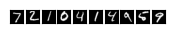

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

n = 10  # how many records we will display
plt.figure(figsize=(2, 2))

for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

![image.png](attachment:7b66c461-7e86-42f8-8fa2-1cb11eaaaaa2.png)

In [11]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, UpSampling2D, Reshape

In [15]:
encode_model = Sequential()

############
# Encoding #
############

## FIRST SET OF LAYERS
# CONVOLUTIONAL LAYER
encode_model.add(Conv2D(filters=16, kernel_size=(3,3), input_shape=(28, 28, 1), activation='relu', padding='same'))
# POOLING LAYER
encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

## SECOND SET OF LAYERS
# CONVOLUTIONAL LAYER
encode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

encode_model.add(Flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
############
# Decoding #
############
decode_model=Sequential()

decode_model.add(Dense(7*7*8,activation="relu"))
decode_model.add(Reshape([7,7,8]))

# DeConv1
decode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# Upsampling LAYER
decode_model.add(UpSampling2D((2, 2)))

# Deconv2
decode_model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
decode_model.add(UpSampling2D((2, 2)))

decode_model.add(Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same'))


In [18]:
autoencoder = Sequential([encode_model, decode_model])

In [21]:
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 392)            │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │       155,953 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,273 (614.35 KB)

 Trainable params: 157,273 (614.35 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras import models

In [26]:
autoencoder.save('Conv_autoencoder.keras')

In [27]:
encode_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
decode_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 392)            │       154,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,953 (609.19 KB)

 Trainable params: 155,953 (609.19 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
x_train = x_train.reshape(60000,28,28,1)
x_train = x_train / 255
x_train.shape

(60000, 28, 28, 1)

In [32]:
x_test = x_test.reshape(10000, 28, 28, 1)
x_test = x_test/255
x_test.shape

(10000, 28, 28, 1)

In [34]:
history = autoencoder.fit(
    x=x_train,
    y=x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 129ms/step - accuracy: 0.8081 - loss: 0.6915 - val_accuracy: 0.7803 - val_loss: 0.6824
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.8088 - loss: 0.6870 - val_accuracy: 0.7933 - val_loss: 0.6799
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.8088 - loss: 0.6811 - val_accuracy: 0.8025 - val_loss: 0.6763
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 124ms/step - accuracy: 0.8088 - loss: 0.6730 - val_accuracy: 0.8069 - val_loss: 0.6709
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - accuracy: 0.8088 - loss: 0.6612 - val_accuracy: 0.8072 - val_loss: 0.6630
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 137ms/step - accuracy: 0.8088 - loss: 0.6430 - val_accuracy: 0.8072 - val_loss: 0.6505
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.8088 - loss: 0.6140 - val_accuracy: 0.8072 - val_loss: 0.6301
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.8088 - loss: 0

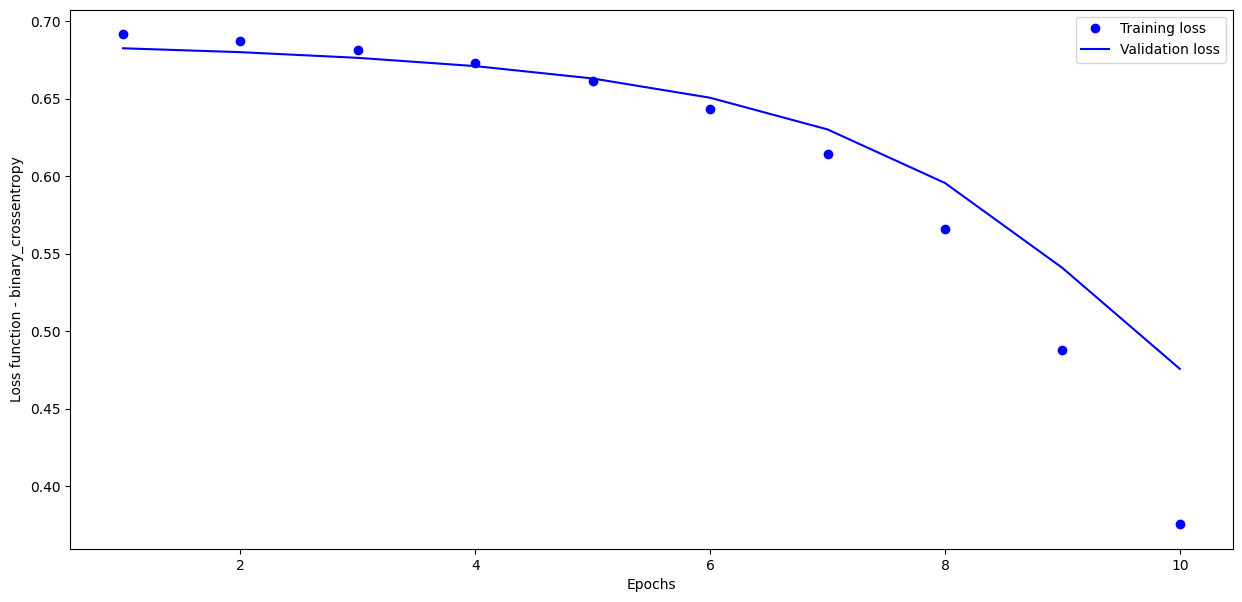

In [35]:
losses = history.history['loss']
losses_val = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

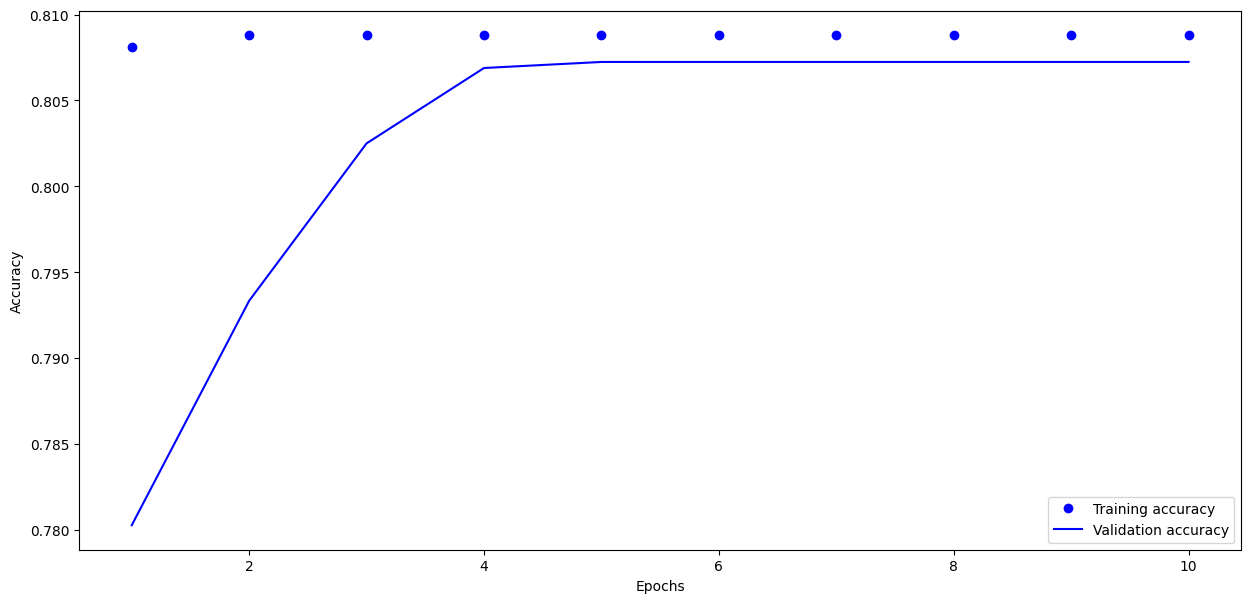

In [37]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


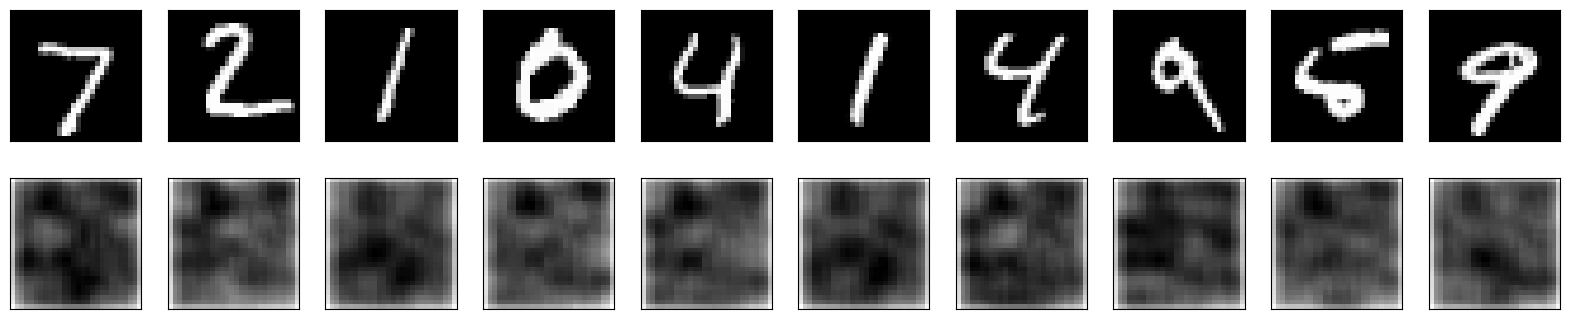

In [39]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
#

![image.png](attachment:f51e6fad-c8b0-48ee-b841-08b51142fe9c.png)

In [ ]:
# optimiser is not so good,
# epoch number should be added

## Lab Logbook requirement:

1) Copy the autoencoder model and train it with epochs=Z+40,
where your SID is: XXXXXXZ

Use "adam" optimaser.

Leave other parameters the same as in Task 2.

3) Please only add to your Lab Logbook print-screens of:
- Table of your model autoencoder.summary()
- Code of your autoencoder.fit()
- Accuracy detailed graph
- Document the plot of the decoded images for task 2. Change the colour, appearance, and shape of the plot according to your own choice (see plt.figure() parameters).


NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.

In [40]:
autoencoder_2 = models.load_model('Conv_autoencoder.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adadelta', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
autoencoder_2.summary()

In [43]:
Z = 1

In [41]:
autoencoder_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_2 = autoencoder_2.fit(
    x=x_train,
    y=x_train,
    epochs= Z + 40,
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)

Epoch 1/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 152ms/step - accuracy: 0.8087 - loss: 0.0310 - val_accuracy: 0.8072 - val_loss: 2.7083
Epoch 2/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 125ms/step - accuracy: 0.8088 - loss: 0.0041 - val_accuracy: 0.8072 - val_loss: 2.4206
Epoch 3/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 132ms/step - accuracy: 0.8088 - loss: 0.0040 - val_accuracy: 0.8072 - val_loss: 2.1862
Epoch 4/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.8088 - loss: 0.0040 - val_accuracy: 0.8072 - val_loss: 1.9525
Epoch 5/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.8088 - loss: 0.0040 - val_accuracy: 0.8072 - val_loss: 1.7148
Epoch 6/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - accuracy: 0.8088 - loss: 0.0040 - val_accuracy: 0.8072 - val_loss: 1.4965
Epoch 7/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.8088 - loss: 0.0040 - val_accuracy: 0.8072 - val_loss: 1.3042
Epoch 8/41
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 122ms/step - accuracy: 0.8088 - loss: 0

In [ ]:
plt.figure(figsize=(15,7))
plt.plot(history.history['loss'], label='Old Training Loss')
plt.plot(history.history['val_loss'], label='Old Validation Loss')

plt.plot(history_2.history['loss'], label='New Training Loss')
plt.plot(history_2.history['val_loss'], label='New Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Comparison')
plt.show()

In [ ]:
plt.figure(figsize=(15,7))
plt.plot(history.history['accuracy'], label='Old Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Old Validation Accuracy')

plt.plot(history_2.history['accuracy'], label='New Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='New Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Comparison')
plt.show()

In [ ]:
# The performance of the autoencoder improved after switching the optimiser from Adadelta to Adam and increasing the number of epochs.

# The Adam optimiser provides faster and more efficient convergence compared to Adadelta, resulting in lower loss and improved accuracy. Additionally, increasing the number of epochs allowed the model to learn more detailed features from the data, improving reconstruction quality.

# From the comparison graphs, the new model shows lower training and validation loss and higher accuracy, indicating better performance. Therefore, using Adam with more epochs significantly enhances the effectiveness of the autoencoder.